# Homework 1 — Regularization of mlp_4out_emb

**Hypothesis** from [mlp.ipynb](mlp.ipynb): mlp_4out_emb overfits (training RMSLE 0.83, validation 1.20, fold averages), so
regularization should help ([Regularization guide](../../../Development%20Guide/Regularization_guide.md)).

**How it's measured:** 4 folds; each validates on one 3-month block of 2016 and trains on the other nine, so every
season is tested ([adversarial.ipynb](../validation/adversarial.ipynb): Oct–Dec alone tests only autumn). Setups are
compared by mean validation RMSLE over the folds.

**Setups**, one change at a time, 10 epochs each:

| Setup               | Change                                                                                 |
| ------------------- | -------------------------------------------------------------------------------------- |
| none                | mlp_4out_emb as in mlp.ipynb                                                           |
| weight decay        | AdamW with weight decay 0.01 on weights and the embedding (not on biases or BatchNorm) |
| strong weight decay | the same with 0.1                                                                      |
| dropout             | dropout 0.2 after each hidden layer                                                    |
| small embedding     | building embedding of 4 numbers instead of 16                                          |
| all three           | weight decay + dropout + small embedding                                               |

**Early stopping** is read from the logged curves: the best epoch of each run.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS
from ashrae.data import read_processed, split
from ashrae.features import build_features
from ashrae.modeling import MeterMLP, make_loaders
from ashrae.plots import plot_curves
from ashrae.tracking import Experiment

EPOCHS = 10
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold
SETUPS = {
    "none": {},
    "weight decay": {"weight_decay": 0.01},
    "strong weight decay": {"weight_decay": 0.1},
    "dropout": {"dropout": 0.2},
    "small embedding": {"emb_dim": 4},
    "all three": {"weight_decay": 0.01, "dropout": 0.2, "emb_dim": 4},
}
experiment = Experiment("ashrae-regularization")

MLflow: sqlite:///mlflow.db, experiment 'ashrae-regularization', session 2026-09-27 10:19:01


## Data and features

Same features as mlp.ipynb. Anomalies are dropped from training only; the scaler is fitted on each fold's training
rows.


In [2]:
df = read_processed()


def fold_loaders(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    return make_loaders(train_df, val_df, build_features(train_df, year_median), build_features(val_df, year_median))


loaders = {name: fold_loaders(months) for name, months in FOLDS.items()}
n_features = loaders["Jan–Mar"][0].dataset.x.shape[1]
n_buildings = int(df.building_id.max()) + 1
del df
print(
    f"{len(FOLDS)} folds, {n_features} features, {N_TRAIN:,} training / {N_VAL:,} validation rows each"
)

4 folds, 33 features, 2,000,000 training / 500,000 validation rows each


## Model

mlp_4out_emb (`MeterMLP` in [ashrae/modeling.py](../ashrae/modeling.py)):

- **Dropout:** after BatchNorm and ReLU, never on the output layer.
- **Weight decay:** AdamW, which decays the weights directly instead of mixing the decay into Adam's adaptive step.
  Applied to weight matrices and the embedding, not to biases or BatchNorm.

## Training

24 runs (6 setups × 4 folds), logged to MLflow. Kept per run: last-epoch validation RMSLE, the best epoch and its
score, last training RMSLE.

In [4]:
def train(setup, fold):
    net_settings = dict(SETUPS[setup])
    weight_decay = net_settings.pop("weight_decay", 0.0)  # the rest (dropout, emb_dim) configure the network
    _, run_id = experiment.fit(lambda: MeterMLP(n_features, n_buildings, **net_settings), *loaders[fold][:2],
                               run_name=f"{setup} | {fold}", epochs=EPOCHS, tags={"setup": setup, "fold": fold},
                               weight_decay=weight_decay)
    val, train_curve = experiment.history(run_id, "val_rmsle"), experiment.history(run_id, "train_rmsle")
    return {"setup": setup, "fold": fold, "val_curve": val, "val_last": val[-1], "val_best": min(val),
            "best_epoch": int(np.argmin(val)) + 1, "train_last": train_curve[-1]}


results = []
for setup in SETUPS:
    for fold in FOLDS:
        results.append(train(setup, fold))
        r = results[-1]
        print(f"{setup:16s} {fold}: val {r['val_last']:.3f} (best {r['val_best']:.3f} at epoch {r['best_epoch']}), "
              f"train {r['train_last']:.3f}")
results = pd.DataFrame(results)

none             Jan–Mar: val 1.421 (best 1.418 at epoch 9), train 0.838


none             Apr–Jun: val 1.222 (best 1.222 at epoch 10), train 0.832


none             Jul–Sep: val 1.048 (best 1.048 at epoch 10), train 0.847


none             Oct–Dec: val 1.111 (best 1.108 at epoch 8), train 0.792


weight decay     Jan–Mar: val 1.421 (best 1.417 at epoch 9), train 0.839


...

small embedding  Oct–Dec: val 1.108 (best 1.105 at epoch 8), train 0.816


all three        Jan–Mar: val 1.437 (best 1.437 at epoch 10), train 1.013


all three        Apr–Jun: val 1.242 (best 1.236 at epoch 9), train 1.011


all three        Jul–Sep: val 1.130 (best 1.130 at epoch 10), train 1.011


all three        Oct–Dec: val 1.117 (best 1.117 at epoch 10), train 0.984


## Results


,val_mean,val_spread,early_stopped,best_epoch,train,gap
setup,,,,,,
none,1.200,0.164,1.199,9.25,0.827,0.373
weight decay,1.200,0.164,1.198,9.25,0.827,0.373
strong weight decay,1.202,0.166,1.197,9.25,0.828,0.373
dropout,1.208,0.159,1.208,9.75,0.972,0.236
small embedding,1.209,0.161,1.207,9.00,0.848,0.361
all three,1.231,0.148,1.230,9.75,1.005,0.226


fold,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec
setup,,,,
none,1.421,1.222,1.048,1.111
weight decay,1.421,1.222,1.047,1.110
strong weight decay,1.426,1.220,1.048,1.113
dropout,1.429,1.219,1.085,1.102
small embedding,1.431,1.223,1.075,1.108
all three,1.437,1.242,1.130,1.117


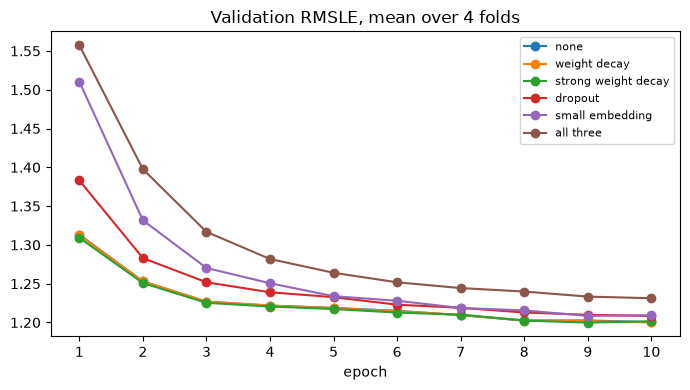

In [5]:
summary = results.groupby("setup", sort=False).agg(
    val_mean=("val_last", "mean"),
    val_spread=("val_last", "std"),
    early_stopped=("val_best", "mean"),
    best_epoch=("best_epoch", "mean"),
    train=("train_last", "mean"),
)
summary["gap"] = summary.val_mean - summary.train
display(summary.round(3))
display(results.pivot(index="setup", columns="fold", values="val_last").loc[list(SETUPS), list(FOLDS)].round(3))

fig, ax = plt.subplots(figsize=(7, 4))
curves = {setup: np.mean(group.val_curve.tolist(), axis=0) for setup, group in results.groupby("setup", sort=False)}
plot_curves(ax, curves, "Validation RMSLE, mean over 4 folds")
plt.tight_layout()

## Findings

- **No regularizer improves validation.** Weight decay (0.01 or 0.1) changes nothing. Dropout and a smaller embedding
  only raise training error. All three together is worst (1.231 vs 1.200).
- **Why weight decay does nothing:** most weights feed a BatchNorm layer, which rescales their output anyway.
- **Early stopping has nothing to stop:** validation still improves at epoch 9–10. Longer training is checked in
  [epochs_test.ipynb](epochs_test.ipynb).
- **One fold would have misled:** on Oct–Dec alone dropout looks like a win (1.111 → 1.102); it loses on the other
  three seasons.
- **The hypothesis was wrong: the gap isn't overfitting.** Of the gap between training (0.83) and validation (1.20),
  0.26 is anomaly rows in validation (zeros no model can predict) and only 0.11 is season plus memorization
  ([season_validation.ipynb](../validation/season_validation.ipynb),
  [mean_vs_embedding.ipynb](../validation/mean_vs_embedding.ipynb)). Regularizers can only act on the small part.

One seed per run; differences below ~0.01 may be noise.